In this notebook we explore Gaussian Processes for processing ESR data. Previous studies have demonstrated that GPs can achieve better than 1 K accuracy in spectra -> temperature mapping


In [48]:
# import modules

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure, show, grid, tight_layout
import datetime
# Make the Jupyter Notebook fill 90 percent of the screen (nerd_mode)
from IPython.display import display, HTML
display(HTML("<style>:root { --jp-notebook-max-width: 90% !important; }</style>"))

# Gaussian Processes
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel, RBF, DotProduct
from sklearn.preprocessing import MinMaxScaler
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning)

Index(['Unnamed: 0', 'frequency', '25up', '30up', '35up', '40down', '45down',
       '50', '45', '40', '35', '30', '25', '20'],
      dtype='object')


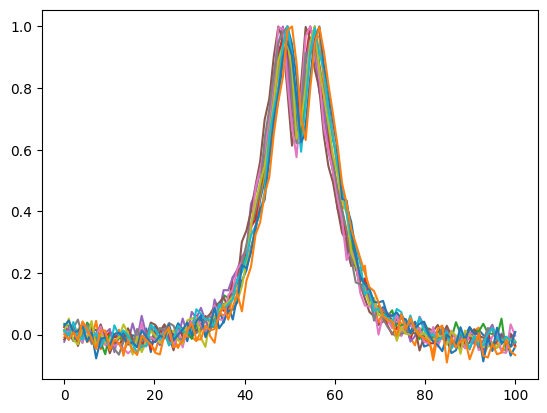

In [49]:
# load cycle 1 data and preprocess it 

temps_ = ['25', '30', '35',
       '40', '45', '50', '45', '40', '35', '30', '25', '20']
c1_temps = np.array(temps_, dtype=float)

## import data file
fpath = '../../esr_data/saved_data/cycle1'

df_= pd.read_csv(fpath, sep=',', header = 0); 
df= df_.iloc[0:, :-1]
df.drop(columns= ['25 C-lower power', '15', '10', '10.1', '-30', "-20"], inplace= True)
print(df.columns)
# df.iloc[:, 2:].plot(legend= False)
plt.show()
# define and scale the frequency axis 
x_esr = df.frequency.values
y_esr = df.iloc[:, 2:]

#scale x axis to 0-100
sc = MinMaxScaler()
x_scale = sc.fit_transform(x_esr.reshape(-1, 1)).flatten()*100

# plot baseline subtracted  y data
y_esr_c1 = y_esr.apply(lambda x: x - x[:10].mean())#+0.01
y_esr_c1 = y_esr_c1/y_esr_c1.min()
y_esr_c1 = y_esr_c1.apply(lambda x: x/x.max())
plt.plot(x_scale, y_esr_c1);
#plt.xlim(40, 80)


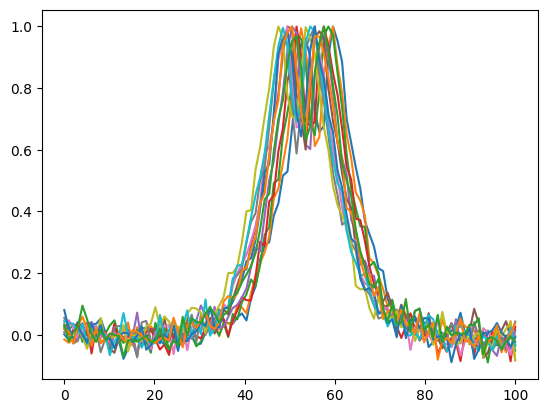

In [50]:
# load cycle 2 data and preprocess it 

temps_ = ['-30', '-20', '-10', '0',
       '10', '20', '30', '40', '50', '40', '30', '20',
       '10', '0', '-10', '-20', '-30']

c2_temps = np.array(temps_[:-4], dtype=float)


## import data file
fpath = '../../esr_data/saved_data/cycle2'

df_= pd.read_csv(fpath, sep=',', header = 0); 
df= df_.iloc[0:, 1:-4]
#df.drop(columns= ['25 C-lower power', '15', '10', '10.1', '-30', '-20'], inplace= True)
# df.iloc[:, 2:].plot(legend= False)
plt.show()
# define and scale the frequency axis 
x_esr = df.frequency.values
y_esr_c2 = df.iloc[:, 1:]

# plt.plot(x_scale, y_esr_c2); plt.show()
#plt.xlim(40, 80)

y_esr_c2 = y_esr_c2.apply(lambda x: x - x[:20].mean())#+0.01
y_esr_c2 = y_esr_c2/y_esr_c2.min()
y_esr_c2 = y_esr_c2.apply(lambda x: x/x.max())
plt.plot(x_scale, y_esr_c2);



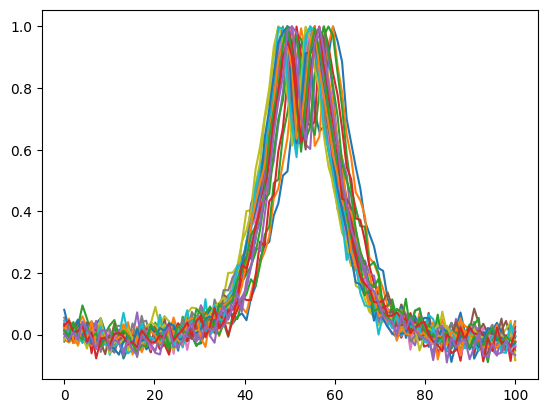

In [51]:
plt.plot(x_scale, y_esr_c2)
plt.plot(x_scale, y_esr_c1)

In [52]:
X_train, X_test, y_train, y_test = y_esr_c2.T, y_esr_c1.T, c2_temps, c1_temps

#train_test_split(y_esr.T, temps, test_size=0.5)

In [53]:

# Define GP kernel
kernel_ = ConstantKernel(1.0) * (Matern(length_scale=0.2, nu=1.5, length_scale_bounds=(0.05, 1.0)) \
        + ConstantKernel(1.0) * Matern(length_scale=5, nu=2.5, length_scale_bounds=(1, 10))) +ConstantKernel(10.)
kernel = ConstantKernel(1.0) *  DotProduct(sigma_0=1.0) * RBF(length_scale=1.) * kernel_
gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-10,
    normalize_y=False,
    n_restarts_optimizer=5
)
    

In [54]:
### fit GP on C2 and test on C1

gp.fit(X_train, y_train)

# Predict mean and std
mu, std = gp.predict(X_test, return_std=True)
mu = mu.flatten()
std = std.flatten()




In [55]:
np.mean(std**2)**0.5

np.float64(3.7347291411565813)

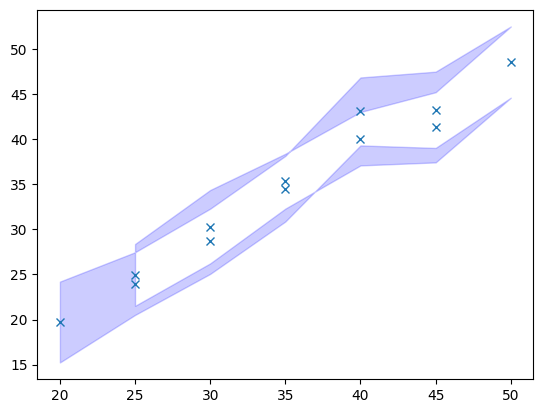

In [56]:
plt.plot(y_test, mu, 'x')
plt.fill_between(y_test, mu - std, mu + std, alpha=0.2, color = 'blue')

Flip the training and testing cycle to c1 and c2, respectively

5.568971680011485


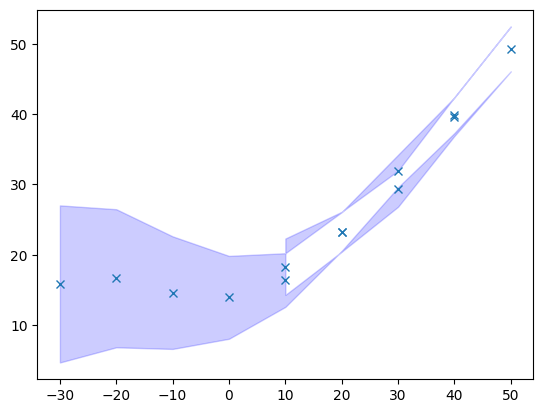

In [57]:
X_train, X_test, y_train, y_test = y_esr_c1.T, y_esr_c2.T, c1_temps, c2_temps



# Define GP kernel
kernel = ConstantKernel(1.0) * (Matern(length_scale=0.2, nu=1.5, length_scale_bounds=(0.05, 1.0)) \
        + ConstantKernel(1.0) * Matern(length_scale=10, nu=10.5, length_scale_bounds=(1, 100))) +ConstantKernel(10.)
gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-10,
    normalize_y=False,
    n_restarts_optimizer=5
)
### fit GP on C1 and test on C2

gp.fit(X_train, y_train)

# Predict mean and std
mu, std = gp.predict(X_test, return_std=True)
mu = mu.flatten()
std = std.flatten()

print(np.sqrt(np.mean(std**2)))

plt.plot(y_test, mu, 'x')
plt.fill_between(y_test, mu - std, mu + std, alpha=0.2, color = 'blue')